<a href="https://colab.research.google.com/github/rguez4828/CURSO_CDIA/blob/master/proyecto_coronario_cdia_nosupervisado.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import warnings

warnings.filterwarnings("ignore")
pd.set_option('future.no_silent_downcasting', True)

url_base = 'https://github.com/rguez4828/CURSO_CDIA/raw/refs/heads/master/Data/Coronario_Nacional/'
nombre_archivo = 'Coronario_DB.csv'
ruta_archivo = url_base + nombre_archivo

df_coronario_clf = pd.read_csv(ruta_archivo)

df_coronario_clf = df_coronario_clf[['Sexo', 'Edad', 'Raza', 'H Fum', 'HTA', 'IMA ant', 'Obes', 'Disl', 'DM', 'IRC', 'Diag ing', 'ECG ing', 'Colest', 'TG', 'Glicemia', 'Ac U', 'Creat', 'Hto', 'Leuc', 'FEVI ', 'C de coro', 'Complic en ACTP', 'Complicac', 'D egreso']].copy()

In [10]:
caracteristica = ['Sexo', 'Raza', 'HTA', 'H Fum', 'Obes', 'Disl', 'DM', 'IMA ant', 'IRC', 'FEVI ' , 'Diag ing', 'ECG ing', 'ROBUST_Edad', 'ROBUST_Colest', 'ROBUST_TG', 'ROBUST_Glicemia', 'ROBUST_Ac U', 'ROBUST_Hto', 'ROBUST_Leuc', 'C de coro', 'Complic en ACTP', 'Complicac']

caracteristica_cuant = ['Edad', 'Colest', 'TG', 'Glicemia', 'Ac U', 'Hto', 'Leuc']
caracteristica_cuali = ['Sexo', 'Raza', 'HTA', 'H Fum', 'Obes', 'Disl', 'DM', 'IMA ant', 'IRC', 'FEVI ' , 'Diag ing', 'ECG ing', 'C de coro', 'Complic en ACTP', 'Complicac', 'D egreso']


etiqueta = 'D egreso'
degreso_map = {1 : 'IMA', 2 : 'IMA no Q.', 3 : 'Otros.', 4 : 'Miocardiopatía.', 5 : 'AIA.', 6 : 'Sincope.', 7 : 'TEP.', 8: 'Angina estable.', 9 : 'Dolor Torácico no precisado.', 10 : 'Trastornos del ritmo y de la conducción.',  11 : 'I Cardiaca.', 12 : 'Pericarditis.'}

In [11]:
df_coronario_clf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1348 entries, 0 to 1347
Data columns (total 24 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Sexo             1348 non-null   float64
 1   Edad             1347 non-null   float64
 2   Raza             1348 non-null   float64
 3   H Fum            1346 non-null   float64
 4   HTA              1346 non-null   float64
 5   IMA ant          1346 non-null   float64
 6   Obes             1346 non-null   float64
 7   Disl             1345 non-null   float64
 8   DM               1346 non-null   float64
 9   IRC              1346 non-null   float64
 10  Diag ing         1348 non-null   float64
 11  ECG ing          1348 non-null   float64
 12  Colest           1172 non-null   float64
 13  TG               1162 non-null   float64
 14  Glicemia         1174 non-null   float64
 15  Ac U             1163 non-null   float64
 16  Creat            758 non-null    float64
 17  Hto           

In [12]:
df_coronario_clf.describe().T

,count,mean,std,min,25%,50%,75%,max
Sexo,1348.0,1.600890,0.489897,1.0,1.0000,2.000,2.0000,2.0
Edad,1347.0,65.564217,12.995061,21.0,56.0000,66.000,75.0000,102.0
Raza,1348.0,1.281157,0.449731,1.0,1.0000,1.000,2.0000,2.0
H Fum,1346.0,1.591382,0.491761,1.0,1.0000,2.000,2.0000,2.0
HTA,1346.0,1.179049,0.383536,1.0,1.0000,1.000,1.0000,2.0
IMA ant,1346.0,1.847697,0.359448,1.0,2.0000,2.000,2.0000,2.0
Obes,1346.0,1.884101,0.320223,1.0,2.0000,2.000,2.0000,2.0
Disl,1345.0,1.898141,0.302575,1.0,2.0000,2.000,2.0000,2.0
DM,1346.0,1.726597,0.445871,1.0,1.0000,2.000,2.0000,2.0
IRC,1346.0,1.961367,0.192790,1.0,2.0000,2.000,2.0000,2.0


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.ensemble import IsolationForest
from sklearn.metrics import silhouette_score
import random

def prepare_mixed_data_for_unsupervised(df, caracteristica_cuant, caracteristica_cuali):
    """
    Prepara datos mixtos (cuantitativos y cualitativos) para análisis no supervisado

    Parameters:
    -----------
    df : pandas.DataFrame
        DataFrame con los datos
    caracteristica_cuant : list
        Lista de nombres de columnas cuantitativas
    caracteristica_cuali : list
        Lista de nombres de columnas cualitativas

    Returns:
    --------
    tuple
        (X_processed, X_numeric, encoders_dict, scaler)
    """
    # Procesar variables cuantitativas
    X_numeric = df[caracteristica_cuant].copy()

    # Manejar valores faltantes en variables cuantitativas
    X_numeric = X_numeric.fillna(X_numeric.median())

    # Procesar variables cualitativas
    X_categorical = df[caracteristica_cuali].copy()

    # Manejar valores faltantes en variables cualitativas
    X_categorical = X_categorical.fillna(X_categorical.mode().iloc[0] if not X_categorical.mode().empty else 'Unknown')

    # Codificar variables cualitativas
    encoders_dict = {}
    X_categorical_encoded = pd.DataFrame()

    for col in caracteristica_cuali:
        if col in X_categorical.columns:
            le = LabelEncoder()
            # Convertir a string para evitar problemas con valores mixtos
            X_categorical[col] = X_categorical[col].astype(str)
            X_categorical_encoded[col] = le.fit_transform(X_categorical[col])
            encoders_dict[col] = le

    # Combinar variables procesadas
    X_processed = pd.concat([X_numeric, X_categorical_encoded], axis=1)

    # Escalar todos los datos
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_processed)
    X_scaled = pd.DataFrame(X_scaled, columns=X_processed.columns)

    print(f"Datos procesados:")
    print(f"- Variables cuantitativas: {len(caracteristica_cuant)}")
    print(f"- Variables cualitativas: {len(caracteristica_cuali)}")
    print(f"- Total de características: {X_processed.shape[1]}")
    print(f"- Total de muestras: {X_processed.shape[0]}")

    return X_scaled, X_numeric, X_categorical_encoded, encoders_dict, scaler

def multiclass_unsupervised_clustering_coronario(df, caracteristica_cuant, caracteristica_cuali,
                                               n_clusters=None, method='kmeans'):
    """
    Realiza clustering no supervisado específico para datos cardiológicos multiclase

    Parameters:
    -----------
    df : pandas.DataFrame
        DataFrame con los datos del proyecto coronario
    caracteristica_cuant : list
        Variables numéricas
    caracteristica_cuali : list
        Variables categóricas
    n_clusters : int, optional
        Número de clusters. Si None, determina automáticamente
    method : str, default='kmeans'
        Método de clustering

    Returns:
    --------
    dict
        Resultados del clustering
    """
    # Preparar datos
    X_scaled, X_numeric, X_categorical, encoders, scaler = prepare_mixed_data_for_unsupervised(
        df, caracteristica_cuant, caracteristica_cuali)

    # Determinar número óptimo de clusters si no se especifica
    if n_clusters is None:
        # Método del codo
        inertias = []
        silhouette_scores = []
        K_range = range(2, min(11, len(X_scaled)//10))  # Limitar según tamaño de datos

        for k in K_range:
            kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
            cluster_labels = kmeans.fit_predict(X_scaled)
            inertias.append(kmeans.inertia_)
            silhouette_scores.append(silhouette_score(X_scaled, cluster_labels))

        # Visualizar método del codo y silhouette
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

        ax1.plot(K_range, inertias, 'bo-')
        ax1.set_xlabel('Número de Clusters (k)')
        ax1.set_ylabel('Inercia')
        ax1.set_title('Método del Codo')
        ax1.grid(True)

        ax2.plot(K_range, silhouette_scores, 'ro-')
        ax2.set_xlabel('Número de Clusters (k)')
        ax2.set_ylabel('Silhouette Score')
        ax2.set_title('Silhouette Analysis')
        ax2.grid(True)

        plt.tight_layout()
        plt.show()

        # Seleccionar número óptimo basado en silhouette score
        n_clusters = K_range[np.argmax(silhouette_scores)]
        print(f"Número óptimo de clusters seleccionado: {n_clusters}")

    # Aplicar clustering
    if method == 'kmeans':
        model = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    else:
        from sklearn.cluster import AgglomerativeClustering
        model = AgglomerativeClustering(n_clusters=n_clusters)

    cluster_labels = model.fit_predict(X_scaled)

    # Calcular métricas
    silhouette_avg = silhouette_score(X_scaled, cluster_labels)

    print(f"\nResultados del Clustering:")
    print(f"Silhouette Score: {silhouette_avg:.3f}")
    print(f"Número de clusters: {n_clusters}")
    print(f"Distribución de clusters:")
    unique, counts = np.unique(cluster_labels, return_counts=True)
    for cluster, count in zip(unique, counts):
        print(f"  Cluster {cluster}: {count} pacientes ({count/len(cluster_labels)*100:.1f}%)")

    # Reducir dimensionalidad para visualización
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled)

    # Visualizar clusters
    plt.figure(figsize=(12, 8))

    # Plot clusters encontrados
    plt.subplot(2, 2, 1)
    scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels, cmap='tab10', alpha=0.7)
    plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} varianza)')
    plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} varianza)')
    plt.title(f'Clusters Encontrados (n={n_clusters})')
    plt.colorbar(scatter)

    # Si hay etiquetas verdaderas, comparar
    if 'D egreso' in df.columns:
        true_labels = df['D egreso'].values
        plt.subplot(2, 2, 2)
        scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=true_labels, cmap='Set1', alpha=0.7)
        plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} varianza)')
        plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} varianza)')
        plt.title('Diagnósticos Verdaderos')
        plt.colorbar(scatter)

    # Análisis de características por cluster
    plt.subplot(2, 2, 3)
    cluster_means = pd.DataFrame()
    for i in range(n_clusters):
        cluster_data = X_scaled[cluster_labels == i]
        cluster_means[f'Cluster_{i}'] = cluster_data.mean()

    # Heatmap de características promedio por cluster
    sns.heatmap(cluster_means.T, annot=False, cmap='RdYlBu_r')
    plt.title('Perfil Promedio por Cluster')
    plt.ylabel('Clusters')
    plt.xlabel('Características (escaladas)')

    # Distribución de tamaños de clusters
    plt.subplot(2, 2, 4)
    plt.bar(range(n_clusters), counts, color=plt.cm.tab10(range(n_clusters)))
    plt.xlabel('Clusters')
    plt.ylabel('Número de Pacientes')
    plt.title('Distribución de Pacientes por Cluster')
    plt.xticks(range(n_clusters))

    plt.tight_layout()
    plt.show()

    return {
        'cluster_labels': cluster_labels,
        'model': model,
        'silhouette_score': silhouette_avg,
        'n_clusters': n_clusters,
        'X_scaled': X_scaled,
        'X_pca': X_pca,
        'scaler': scaler,
        'encoders': encoders
    }

def multiclass_dimensionality_reduction_coronario(df, caracteristica_cuant, caracteristica_cuali,
                                                method='pca', n_components=2):
    """
    Reducción de dimensionalidad para datos cardiológicos multiclase

    Parameters:
    -----------
    df : pandas.DataFrame
        Datos del proyecto coronario
    caracteristica_cuant : list
        Variables numéricas
    caracteristica_cuali : list
        Variables categóricas
    method : str, default='pca'
        Método de reducción ('pca', 'tsne')
    n_components : int, default=2
        Número de componentes

    Returns:
    --------
    array-like
        Datos reducidos
    """
    # Preparar datos
    X_scaled, _, _, _, _ = prepare_mixed_data_for_unsupervised(
        df, caracteristica_cuant, caracteristica_cuali)

    # Aplicar reducción de dimensionalidad
    if method == 'pca':
        reducer = PCA(n_components=n_components)
        title = 'PCA - Datos Cardiológicos'
    elif method == 'tsne':
        reducer = TSNE(n_components=n_components, random_state=42)
        title = 't-SNE - Datos Cardiológicos'

    X_reduced = reducer.fit_transform(X_scaled)

    # Visualizar
    plt.figure(figsize=(12, 5))

    # Scatter plot de datos reducidos
    plt.subplot(1, 2, 1)
    plt.scatter(X_reduced[:, 0], X_reduced[:, 1], alpha=0.7, c='blue')
    plt.xlabel('Componente 1' if method == 'pca' else 't-SNE 1')
    plt.ylabel('Componente 2' if method == 'pca' else 't-SNE 2')
    plt.title(title)

    # Si hay etiquetas verdaderas
    if 'D egreso' in df.columns:
        true_labels = df['D egreso'].values
        plt.subplot(1, 2, 2)
        scatter = plt.scatter(X_reduced[:, 0], X_reduced[:, 1], c=true_labels, cmap='tab20', alpha=0.7)
        plt.xlabel('Componente 1' if method == 'pca' else 't-SNE 1')
        plt.ylabel('Componente 2' if method == 'pca' else 't-SNE 2')
        plt.title('Datos Reducidos con Etiquetas Verdaderas')
        plt.colorbar(scatter)

    plt.tight_layout()
    plt.show()

    # Análisis de varianza explicada (solo para PCA)
    if method == 'pca':
        plt.figure(figsize=(10, 4))

        plt.subplot(1, 2, 1)
        plt.plot(range(1, len(reducer.explained_variance_ratio_) + 1),
                reducer.explained_variance_ratio_, 'bo-')
        plt.xlabel('Componente Principal')
        plt.ylabel('Varianza Explicada')
        plt.title('Varianza Explicada por Componente')
        plt.grid(True)

        plt.subplot(1, 2, 2)
        cumsum_var = np.cumsum(reducer.explained_variance_ratio_)
        plt.plot(range(1, len(cumsum_var) + 1), cumsum_var, 'ro-')
        plt.xlabel('Número de Componentes')
        plt.ylabel('Varianza Explicada Acumulada')
        plt.title('Varianza Explicada Acumulada')
        plt.grid(True)
        plt.axhline(y=0.8, color='k', linestyle='--', alpha=0.7, label='80%')
        plt.axhline(y=0.9, color='k', linestyle=':', alpha=0.7, label='90%')
        plt.legend()

        plt.tight_layout()
        plt.show()

        print(f"Varianza explicada total: {cumsum_var[-1]:.2%}")
        print(f"Componentes para 80% varianza: {np.argmax(cumsum_var >= 0.8) + 1}")
        print(f"Componentes para 90% varianza: {np.argmax(cumsum_var >= 0.9) + 1}")

    return X_reduced

def multiclass_anomaly_detection_coronario(df, caracteristica_cuant, caracteristica_cuali,
                                         method='isolation_forest', contamination=0.1):
    """
    Detección de anomalías en datos cardiológicos multiclase

    Parameters:
    -----------
    df : pandas.DataFrame
        Datos del proyecto coronario
    caracteristica_cuant : list
        Variables numéricas
    caracteristica_cuali : list
        Variables categóricas
    method : str, default='isolation_forest'
        Método de detección
    contamination : float, default=0.1
        Proporción esperada de anomalías

    Returns:
    --------
    array
        Etiquetas de anomalías (-1: anomalía, 1: normal)
    """
    # Preparar datos
    X_scaled, _, _, _, _ = prepare_mixed_data_for_unsupervised(
        df, caracteristica_cuant, caracteristica_cuali)

    # Aplicar detección de anomalías
    if method == 'isolation_forest':
        detector = IsolationForest(contamination=contamination, random_state=42)
    else:
        from sklearn.svm import OneClassSVM
        detector = OneClassSVM(nu=contamination)

    anomaly_labels = detector.fit_predict(X_scaled)

    # Estadísticas
    n_anomalies = np.sum(anomaly_labels == -1)
    n_normal = np.sum(anomaly_labels == 1)
    anomaly_percentage = n_anomalies / len(anomaly_labels) * 100

    print(f"\nDetección de Anomalías:")
    print(f"Método: {method}")
    print(f"Anomalías detectadas: {n_anomalies} ({anomaly_percentage:.1f}%)")
    print(f"Datos normales: {n_normal} ({100-anomaly_percentage:.1f}%)")

    # Visualizar resultados
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled)

    plt.figure(figsize=(15, 5))

    # Plot detección de anomalías
    plt.subplot(1, 3, 1)
    normal_mask = anomaly_labels == 1
    anomaly_mask = anomaly_labels == -1

    plt.scatter(X_pca[normal_mask, 0], X_pca[normal_mask, 1],
                c='blue', label='Normal', alpha=0.6, s=20)
    plt.scatter(X_pca[anomaly_mask, 0], X_pca[anomaly_mask, 1],
                c='red', label='Anomalía', alpha=0.8, s=40)
    plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%})')
    plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%})')
    plt.title('Detección de Anomalías')
    plt.legend()

    # Pie chart
    plt.subplot(1, 3, 2)
    plt.pie([n_normal, n_anomalies], labels=['Normal', 'Anomalía'],
            autopct='%1.1f%%', colors=['lightblue', 'lightcoral'])
    plt.title('Distribución de Anomalías')

    # Si hay etiquetas verdaderas, comparar con diagnósticos
    if 'D egreso' in df.columns:
        plt.subplot(1, 3, 3)
        true_labels = df['D egreso'].values
        # Contar anomalías por diagnóstico
        anomaly_by_diagnosis = {}
        for diag in np.unique(true_labels):
            mask = (true_labels == diag) & (anomaly_labels == -1)
            anomaly_by_diagnosis[diag] = np.sum(mask)

        diagnoses = list(anomaly_by_diagnosis.keys())
        anomalies = list(anomaly_by_diagnosis.values())

        plt.bar(range(len(diagnoses)), anomalies, color='orange', alpha=0.7)
        plt.xlabel('Diagnóstico')
        plt.ylabel('Número de Anomalías')
        plt.title('Anomalías por Diagnóstico')
        plt.xticks(range(len(diagnoses)), diagnoses, rotation=45, ha='right')

    plt.tight_layout()
    plt.show()

    return anomaly_labels

def _coronario_unsupervised_analysis(df, caracteristica_cuant, caracteristica_cuali,
                                   analysis_type='clustering', **kwargs):
    """
    Análisis no supervisado completo para el proyecto coronario

    Parameters:
    -----------
    df : pandas.DataFrame
        DataFrame con datos cardiológicos
    caracteristica_cuant : list
        Variables numéricas
    caracteristica_cuali : list
        Variables categóricas
    analysis_type : str, default='clustering'
        Tipo de análisis ('clustering', 'pca', 'anomaly')
    **kwargs : dict
        Parámetros adicionales para cada tipo de análisis

    Returns:
    --------
    dict
        Resultados del análisis no supervisado
    """
    print("🔍 Iniciando Análisis No Supervisado - Proyecto Coronario")
    print("=" * 60)

    results = {}

    if analysis_type == 'clustering':
        print("📊 Realizando Clustering...")
        results = multiclass_unsupervised_clustering_coronario(
            df, caracteristica_cuant, caracteristica_cuali, **kwargs)

    elif analysis_type == 'pca':
        print("📉 Realizando Reducción de Dimensionalidad...")
        X_reduced = multiclass_dimensionality_reduction_coronario(
            df, caracteristica_cuant, caracteristica_cuali, method='pca', **kwargs)
        results['reduced_data'] = X_reduced

    elif analysis_type == 'tsne':
        print("🎨 Realizando t-SNE...")
        X_reduced = multiclass_dimensionality_reduction_coronario(
            df, caracteristica_cuant, caracteristica_cuali, method='tsne', **kwargs)
        results['reduced_data'] = X_reduced

    elif analysis_type == 'anomaly':
        print("⚠️  Realizando Detección de Anomalías...")
        anomaly_labels = multiclass_anomaly_detection_coronario(
            df, caracteristica_cuant, caracteristica_cuali, **kwargs)
        results['anomaly_labels'] = anomaly_labels

    print("\n✅ Análisis completado exitosamente!")
    return results

# Ejemplo de uso:
# clustering_results = _coronario_unsupervised_analysis(
#     df_coronario_clf,
#     caracteristica_cuant,
#     caracteristica_cuali,
#     analysis_type='clustering',
#     n_clusters=5
# )
#
# pca_results = _coronario_unsupervised_analysis(
#     df_coronario_clf,
#     caracteristica_cuant,
#     caracteristica_cuali,
#     analysis_type='pca'
# )
#
# anomaly_results = _coronario_unsupervised_analysis(
#     df_coronario_clf,
#     caracteristica_cuant,
#     caracteristica_cuali,
#     analysis_type='anomaly',
#     contamination=0.15
# )

🔍 Iniciando Análisis No Supervisado - Proyecto Coronario
📊 Realizando Clustering...
Datos procesados:
- Variables cuantitativas: 7
- Variables cualitativas: 16
- Total de características: 23
- Total de muestras: 1348


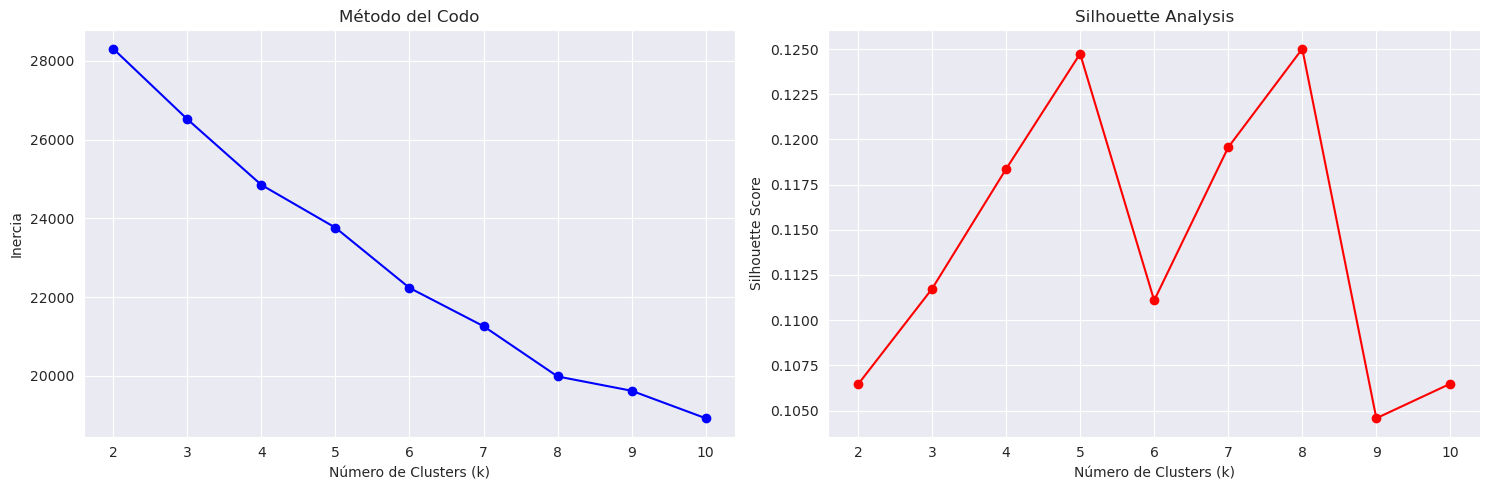

Número óptimo de clusters seleccionado: 8

Resultados del Clustering:
Silhouette Score: 0.125
Número de clusters: 8
Distribución de clusters:
  Cluster 0: 72 pacientes (5.3%)
  Cluster 1: 124 pacientes (9.2%)
  Cluster 2: 432 pacientes (32.0%)
  Cluster 3: 420 pacientes (31.2%)
  Cluster 4: 188 pacientes (13.9%)
  Cluster 5: 104 pacientes (7.7%)
  Cluster 6: 7 pacientes (0.5%)
  Cluster 7: 1 pacientes (0.1%)


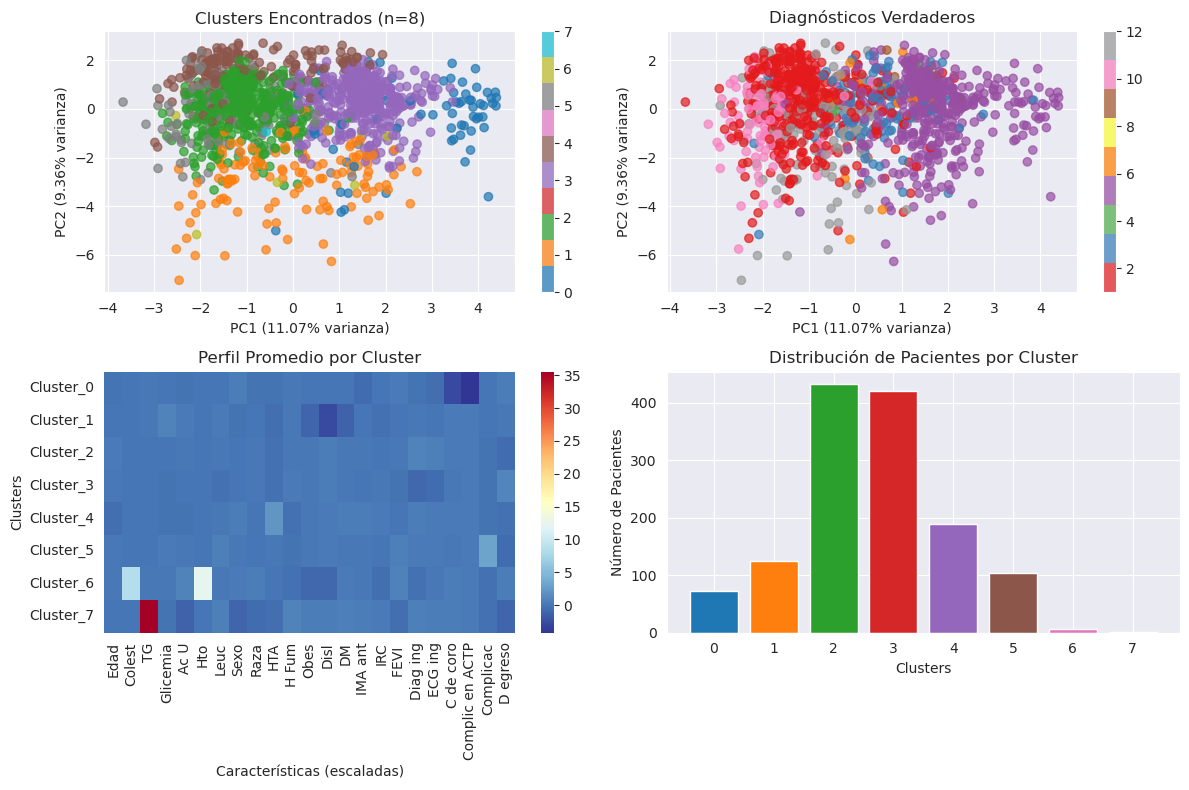


✅ Análisis completado exitosamente!


In [13]:
# Para empezar, prueba clustering:
clustering_results = _coronario_unsupervised_analysis(
    df_coronario_clf,
    caracteristica_cuant,
    caracteristica_cuali,
    analysis_type='clustering'
)

🔍 Iniciando Análisis No Supervisado - Proyecto Coronario
📉 Realizando Reducción de Dimensionalidad...
Datos procesados:
- Variables cuantitativas: 7
- Variables cualitativas: 16
- Total de características: 23
- Total de muestras: 1348


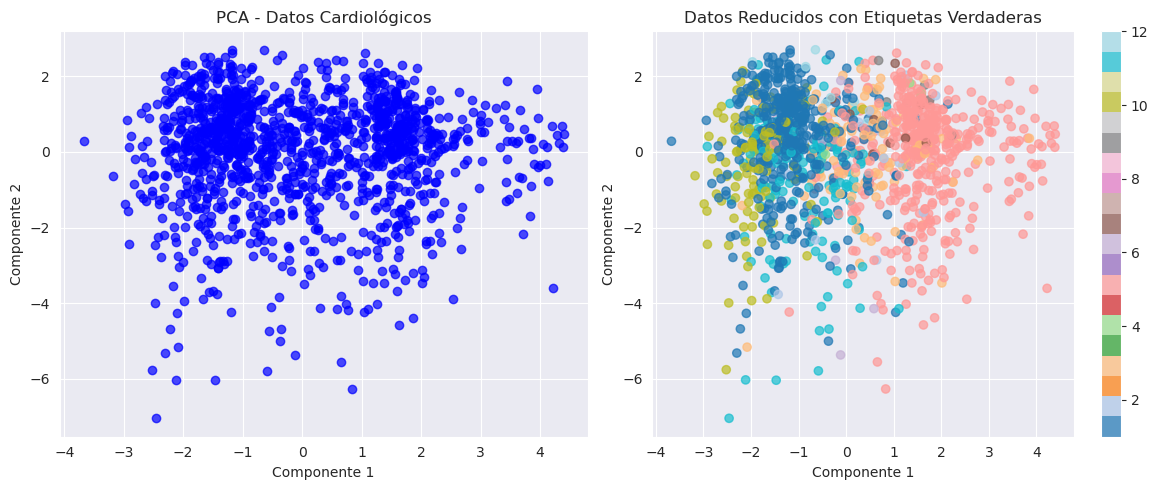

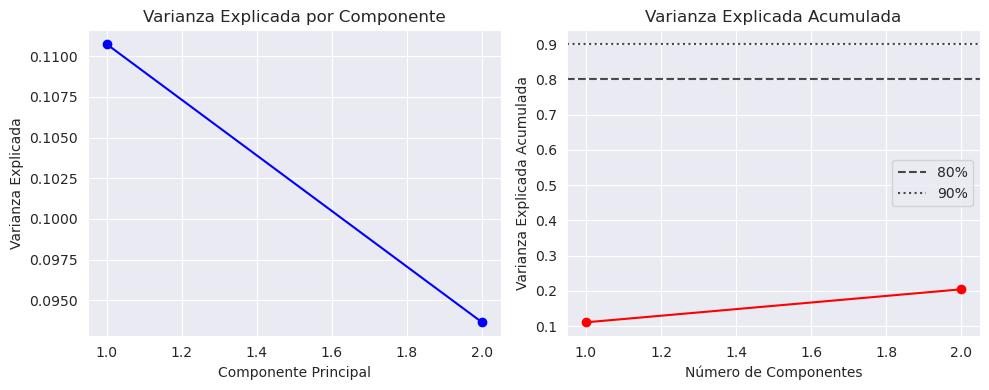

Varianza explicada total: 20.44%
Componentes para 80% varianza: 1
Componentes para 90% varianza: 1

✅ Análisis completado exitosamente!


In [14]:
# Luego explora con PCA:
pca_results = _coronario_unsupervised_analysis(
    df_coronario_clf,
    caracteristica_cuant,
    caracteristica_cuali,
    analysis_type='pca'
)